# [to do] embedding layer -> dbscan to cluster

## [future work] : VAE, อธิบายการนำเสนอ , เก็บ checkpoint แล้ว แต่ตอนนี้ยังไม่ได้เก็บ hyperparameter ในแต่ละครั้งที่จูน

# Read Library

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math
from scipy import stats
import warnings
import re
import datetime
from package.utils import profile_data ,DotDict, timer, get_config, load_data, merge_data ,save_file

In [3]:
from package.model_deep_ae_20250911 import (set_seed,
                                generate_mock_data,
                                expand_rule_columns,
                                subset_by_timeunit,
                                split_train_test,
                                prepare_train_val_test_data,
                                Autoencoder,
                                save_checkpoint,
                                load_checkpoint,
                                train_autoencoder_checkpoint,
                                load_pickled_autoencoder,
                                plot_learning_curve,
                                get_reconstruction_error,
                                flag_anomalies,
                                extract_embeddings,
                                plot_latent_space_2d,
                                plot_latent_space_3d,
                                create_pack_results,
                                create_pack_results_date,
                                evaluate_fraud_predictions,
                                evaluate_thresholds,
                                get_thresholds,
                                map_errors_to_percentiles
                                )

from package.model_deep_ae_20250911 import (
                                run_training_pipeline,
                                run_lookup_threshold_pipeline,
                                run_evaluate_test_pipeline,
                                run_vis_embedding_pipeline
                                )

# Read Data

In [4]:
mock1 = generate_mock_data(n_sales=10000, n_rules=10, fraud_ratio=0.05, seed=42)
mock1

function: generate_mock_data is starting...
function: generate_mock_data successfully executed at 1.9081487655639648s


,sales_id,expected_dt,timeunit,flag_fraud,rule_1,rule_2,rule_3,rule_4,rule_5,rule_6,rule_7,rule_8,rule_9,rule_10
0,0,2024-12-30,l3,0,0.360016,-0.228151,0.282450,-0.724385,-0.585063,1.173842,-1.051548,-0.977754,-0.051581,-0.771890
1,1,2024-07-14,l3,1,2.272585,-0.017009,5.743308,2.880759,5.058952,4.337591,-0.622909,3.658322,2.477348,1.960721
2,2,2025-05-26,l3,0,1.024774,0.908937,-0.997060,-1.057251,-0.411173,-0.026746,-0.657898,1.040642,0.347390,0.406085
3,3,2025-05-25,l3,0,-1.266539,1.167291,-2.820169,0.834055,0.934312,-0.432401,1.272910,-0.063098,0.062432,0.339529
4,4,2025-06-17,l3,0,3.186575,1.344434,0.701131,-0.912804,0.143590,-0.813124,0.822111,0.140467,-1.124522,0.081125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9995,2024-07-01,l36,0,-1.393785,1.119496,-2.225198,0.355354,-1.114918,-0.348127,0.696269,-1.856022,-0.773980,-1.019967
59996,9996,2025-05-03,l36,0,1.914040,-0.250864,-0.670143,0.249901,-0.351280,-0.121383,0.274123,-0.559135,-0.084692,0.955931
59997,9997,2024-10-22,l36,0,0.580123,-0.555800,0.536215,-0.590000,-1.563657,0.052191,0.271158,-0.696574,-1.674949,-1.058655
59998,9998,2024-11-24,l36,0,1.381821,-0.886731,-0.431143,0.390082,0.668774,-1.953408,-0.687125,-1.467512,-0.240759,0.654136


# Autoencoder

- Autoencoder คือ neural network ที่เรียนรู้จะ compress ข้อมูล (encode) แล้ว reconstruct ข้อมูลเดิม (decode) ให้ใกล้เคียงที่สุด
- Encoder → บีบข้อมูลจาก input ขนาดใหญ่เป็น latent space ขนาดเล็ก
- Latent space → ข้อมูลสรุปที่มีมิติเล็กลง (เรียกว่า embedding)
- Decoder → แปลง latent space กลับเป็น input เดิม
- OBJ: เรียนรู้โครงสร้างหรือ pattern ของข้อมูลปกติ

https://fraud-detection-handbook.github.io/fraud-detection-handbook/Chapter_7_DeepLearning/Autoencoders.html

https://www.sciencedirect.com/science/article/pii/S1877050920306840?via%3Dihub

**Application to detect fraud**
- Train autoencoder กับข้อมูลปกติ **[TUNE#1 Architecture]** and **[TUNE#2 Select Features]**
- Predict: ให้ model reconstruct ข้อมูล test
- คำนวณ reconstruction error using MSE โดย ถ้า error สูง → anomaly / fraud <br>
    Normal data → model reconstruct ได้ดี → error ต่ำ <br>
    Anomaly / novel data → model reconstruct ไม่ดี → error สูง <br>
    จึงต้องมีการ **[TUNE#3 Threshold]**

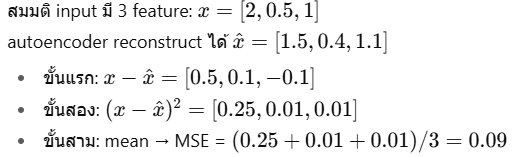

https://www.softnix.co.th/2020/03/24/anomaly-detection-part-5-autoencoder/

## Novelty Detection

### Prep data

In [5]:
df_transformed = expand_rule_columns(mock1)
df_transformed

function: expand_rule_columns is starting...
function: expand_rule_columns successfully executed at 0.49360156059265137s


,sales_id,expected_dt,flag_fraud,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,0,2024-12-30,0,1.294071,-0.033099,-0.771890,1.027978,-1.716319,-0.438359,-0.844588,...,-0.977754,-1.817574,-1.378777,-0.720249,-0.153002,0.147629,-0.051581,-1.928613,-1.005889,-1.700068
1,1,2024-07-14,1,2.970241,1.546394,1.960721,0.327022,1.395264,2.302689,2.134491,...,3.658322,2.169982,4.625339,4.100241,5.391337,4.974683,2.477348,5.201170,0.888200,0.345258
2,2,2025-05-26,0,-0.962456,0.007673,0.406085,-0.324495,-0.351193,-0.073130,-1.225513,...,1.040642,-0.017216,3.053033,1.115441,-2.003674,-0.515232,0.347390,1.687974,-0.886053,0.373724
3,3,2025-05-25,0,-0.557176,0.152205,0.339529,0.084018,0.929277,0.426988,0.121433,...,-0.063098,1.076034,-0.388208,1.075950,-0.600473,-2.693087,0.062432,-0.566217,0.786089,1.194925
4,4,2025-06-17,0,-0.822350,-0.840434,0.081125,-0.962901,-0.471622,-0.433285,1.266659,...,0.140467,-1.761751,-0.281367,1.718366,0.989666,-0.659094,-1.124522,-0.808209,-1.347342,0.004178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,2024-07-01,0,1.743071,-0.215017,-0.953072,-1.019967,-0.682181,1.137971,-0.507696,...,-0.945883,-1.856022,-1.172909,0.589566,0.158376,0.376485,-1.294563,-0.773980,0.137205,-0.786161
9996,9996,2025-05-03,0,0.185918,0.366925,-0.035507,0.955931,-0.901071,-0.267223,-1.110620,...,0.152714,-0.559135,-0.246215,0.267680,-0.556548,1.367107,0.888219,-0.084692,-0.196889,-2.770211
9997,9997,2024-10-22,0,-1.890159,-0.300070,0.348756,-1.058655,1.505729,0.651137,1.225570,...,0.762028,-0.696574,1.745624,-2.129891,0.216331,-1.248463,1.035880,-1.674949,0.124384,-0.070152
9998,9998,2024-11-24,0,-0.321089,0.573540,-0.461097,0.654136,0.506189,-1.361413,0.461321,...,-1.386205,-1.467512,-1.396175,0.997792,0.060714,0.336269,0.143255,-0.240759,-2.010408,-1.628413


In [6]:
df_subset = subset_by_timeunit(df_transformed, ["l3"])
df_subset

function: subset_by_timeunit is starting...
function: subset_by_timeunit successfully executed at 0.0017032623291015625s


,sales_id,expected_dt,flag_fraud,rule_10_l3,rule_1_l3,rule_2_l3,rule_3_l3,rule_4_l3,rule_5_l3,rule_6_l3,rule_7_l3,rule_8_l3,rule_9_l3
0,0,2024-12-30,0,-0.771890,0.360016,-0.228151,0.282450,-0.724385,-0.585063,1.173842,-1.051548,-0.977754,-0.051581
1,1,2024-07-14,1,1.960721,2.272585,-0.017009,5.743308,2.880759,5.058952,4.337591,-0.622909,3.658322,2.477348
2,2,2025-05-26,0,0.406085,1.024774,0.908937,-0.997060,-1.057251,-0.411173,-0.026746,-0.657898,1.040642,0.347390
3,3,2025-05-25,0,0.339529,-1.266539,1.167291,-2.820169,0.834055,0.934312,-0.432401,1.272910,-0.063098,0.062432
4,4,2025-06-17,0,0.081125,3.186575,1.344434,0.701131,-0.912804,0.143590,-0.813124,0.822111,0.140467,-1.124522
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,2024-07-01,0,-0.953072,1.243766,-0.907179,-1.908215,0.990946,-1.512523,-0.014095,1.904482,-0.945883,-1.294563
9996,9996,2025-05-03,0,-0.035507,-1.228504,-1.106326,-1.538331,0.971160,-1.681851,0.651500,-1.649923,0.152714,0.888219
9997,9997,2024-10-22,0,0.348756,-1.213162,-0.045952,-0.537501,-0.188053,-1.289207,0.359176,-0.278025,0.762028,1.035880
9998,9998,2024-11-24,0,-0.461097,-0.321970,-0.769184,-0.872505,0.332159,0.518029,-0.134807,-0.013322,-1.386205,0.143255


In [7]:
# train_all_df, test_df = split_train_test(df_subset)
train_all_df, test_df = split_train_test(df_transformed)

function: split_train_test is starting...
function: split_train_test successfully executed at 0.018739938735961914s


In [8]:
train_all_df

,sales_id,expected_dt,flag_fraud,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,3630,2025-01-09,0,0.789581,-0.571427,-0.122792,1.004332,-0.273505,1.467974,1.307835,...,-0.907257,-0.707563,0.585907,0.544456,-0.782449,-0.798530,0.067369,-0.737219,-1.108168,-0.294903
1,5986,2024-09-11,0,0.369698,-1.136322,-1.810910,-2.192158,1.280891,-0.709141,1.903261,...,-0.289624,-0.090674,0.322351,0.197199,0.375892,-0.920409,-1.331525,-0.016277,-1.086676,0.270081
2,7036,2025-05-28,0,-0.390536,-0.263824,1.651168,-0.772366,0.359175,0.560699,-0.389963,...,-0.391907,-0.321691,-1.234105,-0.487193,-1.103392,-0.185892,-1.567152,0.135463,0.962213,0.308523
3,628,2025-01-09,0,1.297024,0.606710,-1.085953,-0.055662,-0.690931,1.140741,-0.883268,...,-0.071813,-0.824542,-0.415301,0.355717,1.303947,-0.099803,-2.672207,-0.923486,0.883586,1.884059
4,6352,2024-11-30,0,0.382092,0.948331,-1.097125,-0.251941,-1.197393,-0.227360,-0.023993,...,0.048710,-1.671467,0.076069,-0.494949,0.817704,0.111234,-0.708750,-1.267475,-0.609939,-1.320383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,9252,2024-12-25,0,0.610312,0.558819,-1.534743,1.486011,1.223751,0.098766,0.025065,...,1.298804,0.265428,0.257803,1.626610,-1.033954,-0.094529,0.859581,0.989420,-0.130922,-1.050537
7996,5428,2024-12-16,0,0.134426,-0.602359,0.456768,0.098359,1.229681,0.131934,0.275289,...,0.311049,0.071579,-0.882040,-0.030939,1.684502,1.507108,-1.798395,-0.834150,-0.703484,0.368902
7997,5860,2025-02-21,0,-1.040665,-2.199427,-1.223507,1.150970,2.554480,-1.149629,0.530495,...,-1.006606,-1.810087,-1.349829,1.591222,1.262590,0.002762,0.331927,-0.340371,0.690682,1.147406
7998,5684,2025-05-12,0,-0.726755,-0.300747,-0.335984,-2.168752,-0.771411,-0.110201,0.753100,...,-1.383170,-1.882080,0.352121,-0.705427,1.382900,0.184316,0.014605,0.002375,-0.678729,-0.130359


In [9]:
train_all_df['flag_fraud'].value_counts()

flag_fraud
0    7621
1     379
Name: count, dtype: int64

In [10]:
train_all_df['flag_fraud'].value_counts(normalize=True)

flag_fraud
0    0.952625
1    0.047375
Name: proportion, dtype: float64

In [11]:
test_df

,sales_id,expected_dt,flag_fraud,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,8751,2024-12-26,0,0.798646,1.910989,-0.682210,0.424926,-1.310464,-0.159852,1.026974,...,-0.293970,-0.800502,0.415709,0.394036,-0.842713,1.256972,0.869192,-1.737545,-0.519668,-0.816122
1,3108,2024-11-01,0,-0.555605,0.730730,1.181475,-0.037051,1.372782,-0.862182,0.231596,...,-0.684921,-1.646365,-0.472107,-0.325467,1.423782,0.915487,-0.360646,0.227369,1.185418,-0.617715
2,7395,2025-05-09,0,-2.177425,1.464783,0.949450,-2.652735,-0.323935,-0.288479,1.572847,...,-0.835385,1.554332,-0.070805,-0.733257,-0.903604,0.163703,0.361375,0.620957,-0.306494,-1.036489
3,1373,2024-08-04,0,-0.074699,-1.011416,-0.316521,0.904059,-0.085413,-0.956141,1.158787,...,0.812321,0.411823,0.964708,-0.823430,-1.245430,-0.561469,-0.406162,-0.621298,1.358561,0.600808
4,1858,2024-11-11,0,0.751402,0.627102,1.177705,-1.458779,-1.420252,0.408476,0.911883,...,-0.080884,-0.020651,0.819578,-0.832959,1.338492,0.330601,0.517684,0.712518,0.574394,1.251943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,3178,2025-04-29,0,-1.137132,0.194624,-0.176596,-1.727917,0.854812,0.089249,0.135637,...,-0.585872,-0.716755,-1.262167,-0.396327,-0.640715,-1.009249,-0.336405,0.919093,-0.277911,1.903558
1996,9980,2025-02-08,0,-0.213127,-0.605733,-1.569894,0.152895,0.959610,-0.700119,2.420643,...,0.301153,0.348440,1.092087,0.947833,0.790195,0.175799,0.616660,0.008679,0.867330,0.971056
1997,1440,2025-02-17,1,3.401023,0.446424,6.905169,3.912749,2.055033,-0.537756,5.523634,...,3.261699,4.511497,4.965434,1.237663,1.668512,5.471353,-1.403755,4.089967,3.763217,0.479352
1998,8684,2024-12-05,0,-2.256141,-0.652300,-0.467944,-0.007293,0.371925,0.962237,0.103078,...,0.511378,-0.926029,0.372627,-0.689930,0.758842,-0.504341,1.455674,0.441432,-1.449011,0.748324


In [12]:
test_df['flag_fraud'].value_counts()

flag_fraud
0    1905
1      95
Name: count, dtype: int64

In [13]:
test_df['flag_fraud'].value_counts(normalize=True)

flag_fraud
0    0.9525
1    0.0475
Name: proportion, dtype: float64

# Start ตรงนี้หลังรับ Data มาจากฝ้าย

In [14]:
train_all_df

,sales_id,expected_dt,flag_fraud,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,3630,2025-01-09,0,0.789581,-0.571427,-0.122792,1.004332,-0.273505,1.467974,1.307835,...,-0.907257,-0.707563,0.585907,0.544456,-0.782449,-0.798530,0.067369,-0.737219,-1.108168,-0.294903
1,5986,2024-09-11,0,0.369698,-1.136322,-1.810910,-2.192158,1.280891,-0.709141,1.903261,...,-0.289624,-0.090674,0.322351,0.197199,0.375892,-0.920409,-1.331525,-0.016277,-1.086676,0.270081
2,7036,2025-05-28,0,-0.390536,-0.263824,1.651168,-0.772366,0.359175,0.560699,-0.389963,...,-0.391907,-0.321691,-1.234105,-0.487193,-1.103392,-0.185892,-1.567152,0.135463,0.962213,0.308523
3,628,2025-01-09,0,1.297024,0.606710,-1.085953,-0.055662,-0.690931,1.140741,-0.883268,...,-0.071813,-0.824542,-0.415301,0.355717,1.303947,-0.099803,-2.672207,-0.923486,0.883586,1.884059
4,6352,2024-11-30,0,0.382092,0.948331,-1.097125,-0.251941,-1.197393,-0.227360,-0.023993,...,0.048710,-1.671467,0.076069,-0.494949,0.817704,0.111234,-0.708750,-1.267475,-0.609939,-1.320383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,9252,2024-12-25,0,0.610312,0.558819,-1.534743,1.486011,1.223751,0.098766,0.025065,...,1.298804,0.265428,0.257803,1.626610,-1.033954,-0.094529,0.859581,0.989420,-0.130922,-1.050537
7996,5428,2024-12-16,0,0.134426,-0.602359,0.456768,0.098359,1.229681,0.131934,0.275289,...,0.311049,0.071579,-0.882040,-0.030939,1.684502,1.507108,-1.798395,-0.834150,-0.703484,0.368902
7997,5860,2025-02-21,0,-1.040665,-2.199427,-1.223507,1.150970,2.554480,-1.149629,0.530495,...,-1.006606,-1.810087,-1.349829,1.591222,1.262590,0.002762,0.331927,-0.340371,0.690682,1.147406
7998,5684,2025-05-12,0,-0.726755,-0.300747,-0.335984,-2.168752,-0.771411,-0.110201,0.753100,...,-1.383170,-1.882080,0.352121,-0.705427,1.382900,0.184316,0.014605,0.002375,-0.678729,-0.130359


In [15]:
test_df

,sales_id,expected_dt,flag_fraud,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,8751,2024-12-26,0,0.798646,1.910989,-0.682210,0.424926,-1.310464,-0.159852,1.026974,...,-0.293970,-0.800502,0.415709,0.394036,-0.842713,1.256972,0.869192,-1.737545,-0.519668,-0.816122
1,3108,2024-11-01,0,-0.555605,0.730730,1.181475,-0.037051,1.372782,-0.862182,0.231596,...,-0.684921,-1.646365,-0.472107,-0.325467,1.423782,0.915487,-0.360646,0.227369,1.185418,-0.617715
2,7395,2025-05-09,0,-2.177425,1.464783,0.949450,-2.652735,-0.323935,-0.288479,1.572847,...,-0.835385,1.554332,-0.070805,-0.733257,-0.903604,0.163703,0.361375,0.620957,-0.306494,-1.036489
3,1373,2024-08-04,0,-0.074699,-1.011416,-0.316521,0.904059,-0.085413,-0.956141,1.158787,...,0.812321,0.411823,0.964708,-0.823430,-1.245430,-0.561469,-0.406162,-0.621298,1.358561,0.600808
4,1858,2024-11-11,0,0.751402,0.627102,1.177705,-1.458779,-1.420252,0.408476,0.911883,...,-0.080884,-0.020651,0.819578,-0.832959,1.338492,0.330601,0.517684,0.712518,0.574394,1.251943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,3178,2025-04-29,0,-1.137132,0.194624,-0.176596,-1.727917,0.854812,0.089249,0.135637,...,-0.585872,-0.716755,-1.262167,-0.396327,-0.640715,-1.009249,-0.336405,0.919093,-0.277911,1.903558
1996,9980,2025-02-08,0,-0.213127,-0.605733,-1.569894,0.152895,0.959610,-0.700119,2.420643,...,0.301153,0.348440,1.092087,0.947833,0.790195,0.175799,0.616660,0.008679,0.867330,0.971056
1997,1440,2025-02-17,1,3.401023,0.446424,6.905169,3.912749,2.055033,-0.537756,5.523634,...,3.261699,4.511497,4.965434,1.237663,1.668512,5.471353,-1.403755,4.089967,3.763217,0.479352
1998,8684,2024-12-05,0,-2.256141,-0.652300,-0.467944,-0.007293,0.371925,0.962237,0.103078,...,0.511378,-0.926029,0.372627,-0.689930,0.758842,-0.504341,1.455674,0.441432,-1.449011,0.748324


In [16]:
train_t_df = train_all_df.drop(columns='expected_dt')
train_t_df

,sales_id,flag_fraud,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,rule_1_l24,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,3630,0,0.789581,-0.571427,-0.122792,1.004332,-0.273505,1.467974,1.307835,-1.315621,...,-0.907257,-0.707563,0.585907,0.544456,-0.782449,-0.798530,0.067369,-0.737219,-1.108168,-0.294903
1,5986,0,0.369698,-1.136322,-1.810910,-2.192158,1.280891,-0.709141,1.903261,2.141594,...,-0.289624,-0.090674,0.322351,0.197199,0.375892,-0.920409,-1.331525,-0.016277,-1.086676,0.270081
2,7036,0,-0.390536,-0.263824,1.651168,-0.772366,0.359175,0.560699,-0.389963,-0.142301,...,-0.391907,-0.321691,-1.234105,-0.487193,-1.103392,-0.185892,-1.567152,0.135463,0.962213,0.308523
3,628,0,1.297024,0.606710,-1.085953,-0.055662,-0.690931,1.140741,-0.883268,-1.210047,...,-0.071813,-0.824542,-0.415301,0.355717,1.303947,-0.099803,-2.672207,-0.923486,0.883586,1.884059
4,6352,0,0.382092,0.948331,-1.097125,-0.251941,-1.197393,-0.227360,-0.023993,-0.189681,...,0.048710,-1.671467,0.076069,-0.494949,0.817704,0.111234,-0.708750,-1.267475,-0.609939,-1.320383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,9252,0,0.610312,0.558819,-1.534743,1.486011,1.223751,0.098766,0.025065,-0.122803,...,1.298804,0.265428,0.257803,1.626610,-1.033954,-0.094529,0.859581,0.989420,-0.130922,-1.050537
7996,5428,0,0.134426,-0.602359,0.456768,0.098359,1.229681,0.131934,0.275289,-0.661305,...,0.311049,0.071579,-0.882040,-0.030939,1.684502,1.507108,-1.798395,-0.834150,-0.703484,0.368902
7997,5860,0,-1.040665,-2.199427,-1.223507,1.150970,2.554480,-1.149629,0.530495,-2.114538,...,-1.006606,-1.810087,-1.349829,1.591222,1.262590,0.002762,0.331927,-0.340371,0.690682,1.147406
7998,5684,0,-0.726755,-0.300747,-0.335984,-2.168752,-0.771411,-0.110201,0.753100,0.142161,...,-1.383170,-1.882080,0.352121,-0.705427,1.382900,0.184316,0.014605,0.002375,-0.678729,-0.130359


In [17]:
test_t_df = test_df.drop(columns='expected_dt')
test_t_df

,sales_id,flag_fraud,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,rule_1_l24,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,8751,0,0.798646,1.910989,-0.682210,0.424926,-1.310464,-0.159852,1.026974,-0.799381,...,-0.293970,-0.800502,0.415709,0.394036,-0.842713,1.256972,0.869192,-1.737545,-0.519668,-0.816122
1,3108,0,-0.555605,0.730730,1.181475,-0.037051,1.372782,-0.862182,0.231596,0.982961,...,-0.684921,-1.646365,-0.472107,-0.325467,1.423782,0.915487,-0.360646,0.227369,1.185418,-0.617715
2,7395,0,-2.177425,1.464783,0.949450,-2.652735,-0.323935,-0.288479,1.572847,-0.418961,...,-0.835385,1.554332,-0.070805,-0.733257,-0.903604,0.163703,0.361375,0.620957,-0.306494,-1.036489
3,1373,0,-0.074699,-1.011416,-0.316521,0.904059,-0.085413,-0.956141,1.158787,-0.447172,...,0.812321,0.411823,0.964708,-0.823430,-1.245430,-0.561469,-0.406162,-0.621298,1.358561,0.600808
4,1858,0,0.751402,0.627102,1.177705,-1.458779,-1.420252,0.408476,0.911883,0.318527,...,-0.080884,-0.020651,0.819578,-0.832959,1.338492,0.330601,0.517684,0.712518,0.574394,1.251943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,3178,0,-1.137132,0.194624,-0.176596,-1.727917,0.854812,0.089249,0.135637,-0.328038,...,-0.585872,-0.716755,-1.262167,-0.396327,-0.640715,-1.009249,-0.336405,0.919093,-0.277911,1.903558
1996,9980,0,-0.213127,-0.605733,-1.569894,0.152895,0.959610,-0.700119,2.420643,-1.251015,...,0.301153,0.348440,1.092087,0.947833,0.790195,0.175799,0.616660,0.008679,0.867330,0.971056
1997,1440,1,3.401023,0.446424,6.905169,3.912749,2.055033,-0.537756,5.523634,2.935200,...,3.261699,4.511497,4.965434,1.237663,1.668512,5.471353,-1.403755,4.089967,3.763217,0.479352
1998,8684,0,-2.256141,-0.652300,-0.467944,-0.007293,0.371925,0.962237,0.103078,0.599366,...,0.511378,-0.926029,0.372627,-0.689930,0.758842,-0.504341,1.455674,0.441432,-1.449011,0.748324


In [18]:
(all_df, X_scaled_all, y_all , 
train_all_df, X_scaled_train_all,y_train_all,
train_nonfraud_df, X_scaled_train_nonfraud, y_train_nonfraud, 
X_scaled_train, X_scaled_val, X_scaled_test, y_test) = prepare_train_val_test_data(train_df=train_all_df, 
                                                                                    test_df=test_df, 
                                                                                    pk="sales_id", 
                                                                                    date_col="expected_dt",
                                                                                    target="flag_fraud",
                                                                                    val_size=0.2, 
                                                                                    random_state=42, 
                                                                                    scale=True)

function: prepare_train_val_test_data is starting...
Data Prepared:
all_df            : (10000, 63)
X_all             : (10000, 60), y_all: (10000,)
train_all_df      : (8000, 63)
X_train_all       : (8000, 60), y_train_all: (8000,)
train_nonfraud_df : (7621, 63)
X_train_nonfraud  : (7621, 60), y_train_nonfraud: (7621,)
X_train           : (6096, 60)
X_val             : (1525, 60)
X_test            : (2000, 60), y_test: (2000,)
--------------------------------------------------
function: prepare_train_val_test_data successfully executed at 0.05644345283508301s


In [19]:
X_scaled_train_all.to_csv('data/X_scaled_train_all.csv',index=False)
X_scaled_test.to_csv('data/X_scaled_test.csv',index=False)

In [20]:
# Task Train
X_scaled_train.shape # Train on non-fraud only

(6096, 60)

In [21]:
# Task Train
X_scaled_val.shape # val non-fraud only (sep from train)

(1525, 60)

In [22]:
# Task Lookup Threshold 
X_scaled_train_all.shape # All Train Dataset

(8000, 60)

In [23]:
# Task Lookup Threshold 
y_train_all.shape # All Train Dataset - Non Fraud

(8000,)

In [24]:
# Task Lookup Threshold
train_all_df.shape # All Train Dataset for key

(8000, 63)

In [25]:
# Task Evaluate
X_scaled_test.shape # Test on all agent, even if it contains fraud, because you’re looking at the reconstruction error to flag anomalies

(2000, 60)

In [26]:
# Task Evaluate
y_test.shape

(2000,)

In [27]:
# Task Visualize
X_scaled_all.shape # all dataset train+test

(10000, 60)

In [28]:
# Task Visualize
y_all.shape # all dataset train+test

(10000,)

In [29]:
# Task Visualize
all_df.shape # all dataset train+test for key

(10000, 63)

In [30]:
all_df.to_csv('data/all_df.csv',index=False)
X_scaled_all.to_csv('data/X_scaled_all.csv',index=False)
y_all.to_csv('data/y_all.csv',index=False)

In [31]:
true_fraud_test_list = test_df.loc[test_df['flag_fraud']==1,'sales_id'].to_list()
true_fraud_train_all_list = train_all_df.loc[train_all_df['flag_fraud']==1,'sales_id'].to_list()
true_fraud_list = true_fraud_test_list + true_fraud_train_all_list
len(true_fraud_list)

474

# Task Train

### defining the architecture of the autoencoder
- Building the layers (nn.Linear, nn.ReLU, etc.)
- Structuring the encoder and decoder using nn.Sequential
- Defining the forward() function for how data flows through the network
  <br><br>
**But this does not train anything yet.**

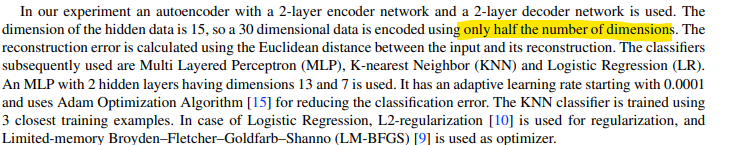

In [32]:
# design arch
in_x = X_scaled_train.shape[1] # จำนวน features -> input_dim
h1 = X_scaled_train.shape[1]//2 #  -> number of neuron in hidden layer 1
h2 = X_scaled_train.shape[1]//4 # -> hidden 2
h3 = X_scaled_train.shape[1]//8 # -> hidden 3

print(f'input layer dim = {in_x}')
print(f'hidden layer dim #1 = {h1}')
print(f'hidden layer dim #2 = {h2}')
print(f'hidden layer dim #3 = {h3}')

input layer dim = 60
hidden layer dim #1 = 30
hidden layer dim #2 = 15
hidden layer dim #3 = 7


In [33]:
from torchinfo import summary
set_seed(42)

model_ae = Autoencoder(input_dim=in_x, 
                         encoding_dim=3, 
                         hidden_layers=[h1, 
                                        h2,
                                        h3,
                                       ],
                         dropout=0.2,
                         verbose=False,
                         seed=42
                        )

# This is only used for testing the model architecture, not training or evaluating on real data.
dummy_input = torch.randn(5, X_scaled_train.shape[1]) 
summary(model_ae, input_data=dummy_input, verbose=0)

function: set_seed is starting...
function: set_seed successfully executed at 0.01563739776611328s


Layer (type:depth-idx)                   Output Shape              Param #
Autoencoder                              [5, 60]                   --
├─Sequential: 1-1                        --                        --
│    └─Linear: 2-1                       [5, 30]                   1,830
│    └─ReLU: 2-2                         [5, 30]                   --
│    └─Dropout: 2-3                      [5, 30]                   --
│    └─Linear: 2-4                       [5, 15]                   465
│    └─ReLU: 2-5                         [5, 15]                   --
│    └─Dropout: 2-6                      [5, 15]                   --
│    └─Linear: 2-7                       [5, 7]                    112
│    └─ReLU: 2-8                         [5, 7]                    --
│    └─Dropout: 2-9                      [5, 7]                    --
│    └─Linear: 2-10                      [5, 3]                    24
├─Sequential: 1-2                        --                        --
│    └─Lin

#### train model to learn normal pattern
It trains an Autoencoder model to reconstruct its input, using mean squared error (MSE) as the loss. 
This lets the model learn the “normal pattern” of your data which you'll later use to detect anomalies.

#### loss  function and optimizer

https://docs.pytorch.org/docs/stable/nn.html#loss-functions

https://medium.com/@chalat.phum/mse-rmse-mae-%E0%B9%80%E0%B8%A5%E0%B8%B7%E0%B8%AD%E0%B8%81%E0%B9%83%E0%B8%8A%E0%B9%89%E0%B8%A2%E0%B8%B1%E0%B8%87%E0%B9%84%E0%B8%87%E0%B8%94%E0%B8%B5%E0%B8%A1%E0%B8%B2%E0%B8%A5%E0%B8%AD%E0%B8%87%E0%B8%94%E0%B8%B9%E0%B8%97%E0%B8%B5%E0%B9%88%E0%B8%84%E0%B8%A7%E0%B8%B2%E0%B8%A1%E0%B8%AB%E0%B8%A1%E0%B8%B2%E0%B8%A2-17b37b0b14b3

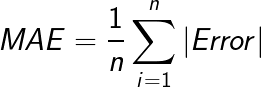

default : MAE เพราะ
1. Robust to Outliers – MAE จะไม่ขยายค่า error ของ outlier ให้มากเกินไปเหมือน MSE (Mean Squared Error) ทำให้ autoencoder ไม่ถูก bias โดยค่าผิดปกติที่รุนแรง ซึ่งเหมาะกับ fraud detection ที่ anomaly มักจะเป็น extreme values

2. Interpretability – ค่าของ MAE ตีความได้ง่ายกว่า เพราะเป็นค่าเฉลี่ยของ absolute difference ระหว่าง input และ reconstruction ทำให้ threshold ในการตัดสิน fraud/non-fraud ดูตรงไปตรงมากว่า

3. Stable Reconstruction Error – MAE ช่วยให้ reconstruction error มีความกระจาย (distribution) ที่ค่อนข้างสม่ำเสมอ ไม่ถูกดันให้ skewed เหมือน MSE ซึ่งจะทำให้การแยกปกติ vs anomaly ด้วย threshold ชัดเจนขึ้น

| **Loss Function**                                          | **When to Use / Pros**                                                                                                     | **PyTorch Implementation**                      |
| ---------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------- |
| **Mean Squared Error (MSE)** (`nn.MSELoss()`)              | Default for continuous features. Penalizes larger errors more. Good when reconstruction of numeric values matters.         | `loss_fn = nn.MSELoss()`                        |
| **Mean Absolute Error (MAE)** (`nn.L1Loss()`)              | More robust to outliers than MSE. Good if anomalies have very large deviations and you don’t want them to dominate.        | `loss_fn = nn.L1Loss()`                         |
| **Huber Loss (Smooth L1)** (`nn.SmoothL1Loss()`)           | A mix of MSE and MAE. Linear for small errors, quadratic for large ones. Balanced robustness.                              | `loss_fn = nn.SmoothL1Loss(beta=1.0)`           |
| **Binary Cross-Entropy (BCE)** (`nn.BCELoss()`)            | Use when inputs are binary or scaled \[0,1]. Common in **image autoencoders (pixel intensity)**.                           | `loss_fn = nn.BCELoss()`                        |
| **BCE with Logits** (`nn.BCEWithLogitsLoss()`)             | Same as BCE but more numerically stable (avoids log(0)). Use if your decoder doesn’t already apply `sigmoid()`.            | `loss_fn = nn.BCEWithLogitsLoss()`              |
| **Kullback-Leibler Divergence (KLDiv)** (`nn.KLDivLoss()`) | Used in **Variational Autoencoders (VAE)** to regularize latent space. Not standalone — combined with reconstruction loss. | `loss_fn = nn.KLDivLoss(reduction="batchmean")` |
| **Cosine Similarity Loss** (`nn.CosineEmbeddingLoss`)      | Useful if you care about *direction* of vectors (embeddings) rather than magnitude.                                        | `loss_fn = nn.CosineEmbeddingLoss()`            |
| **Custom Weighted Loss**                                   | Weight certain features more (e.g., categorical vs numerical).                                                             | `loss = torch.mean(weights * (x - x_hat)**2)`   |


https://docs.pytorch.org/docs/stable/optim.html

default : Adam

| Optimizer                     | Description / When to Use                                                                      |
| ----------------------------- | ---------------------------------------------------------------------------------------------- |
| **Adam** (`optim.Adam`)       | Default choice for autoencoders; adaptive learning rate, generally stable and fast.            |
| **AdamW** (`optim.AdamW`)     | Variant of Adam with better weight decay handling; improves regularization for dense networks. |
| **RMSProp** (`optim.RMSprop`) | Can help stabilize training if gradients are noisy; sometimes useful for deeper autoencoders.  |

In PyTorch, tensors are the main data structure for storing inputs, outputs, and model parameters.
<br>
A device is the hardware that will do computations with these tensors: <br>
CPU: your computer’s main processor. <br>
GPU: a specialized processor for fast parallel computations (much faster for deep learning).
<br>
Every tensor and model must be on the same device for training.

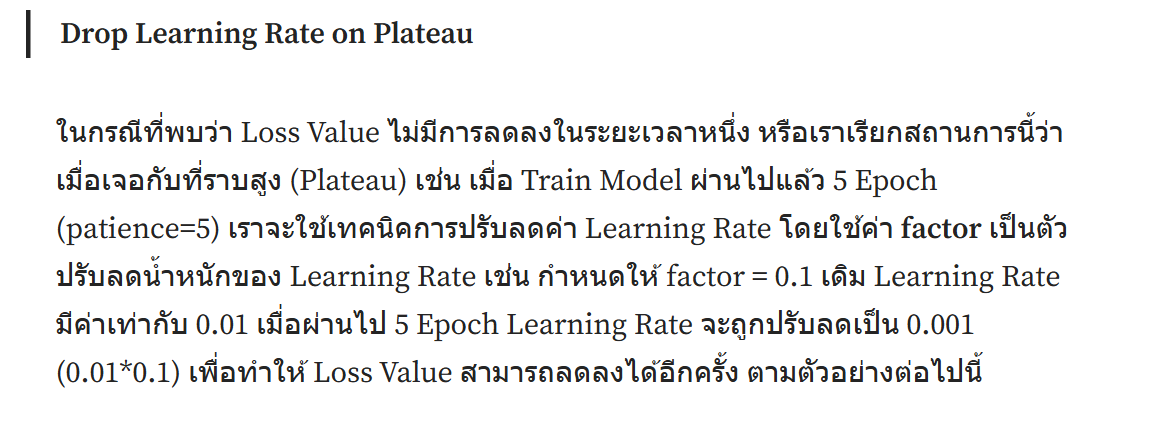

In [36]:
# model_ae = Autoencoder(input_dim=in_x, 
#                          encoding_dim=3, 
#                          hidden_layers=[h1, 
#                                         h2,
#                                         h3,
#                                        ],
#                          dropout=0.2,
#                          verbose=False,
#                          seed=42
#                         )

# trained_model, train_losses, val_losses = train_autoencoder_checkpoint(
#     model = model_ae, 
#     X_train = X_scaled_train, 
#     X_val = X_scaled_val, 
#     epochs=20, 
#     checkpoint_every=10, 
#     early_stopping_patience=10,
#     run_dir="model_checkpoint",
#     loss_name="mae", 
#     optimizer_name="adam",
#     # scheduler_name=None,
#     scheduler_name="plateau",
#     # scheduler_params=None,
#     scheduler_params={"factor": 0.2, "patience": 5
#     #                   # ,"step_size":5
#                      }
# )

function: train_autoencoder_checkpoint is starting...
[INFO] Using device: cpu
[INFO] DataLoader seed info:
       Global generator manual_seed: 42
       Torch initial seed: 42
       Generator state (deterministic): True
       Benchmark mode: False
[INFO] Using loss function: L1Loss
[INFO] Using optimizer: Adam, LR: 0.001000
function: get_scheduler is starting...
function: get_scheduler successfully executed at 5.602836608886719e-05s
[INFO] Using scheduler: ReduceLROnPlateau with params: {'factor': 0.2, 'patience': 5, 'step_size': 10}
Epoch [1/20] - Train Loss: 0.7988, Val Loss: 0.7997
✅ Early stopping is enabled (patience=10)
Epoch [2/20] - Train Loss: 0.7976, Val Loss: 0.7988
Epoch [3/20] - Train Loss: 0.7965, Val Loss: 0.7975
Epoch [4/20] - Train Loss: 0.7956, Val Loss: 0.7963
Epoch [5/20] - Train Loss: 0.7950, Val Loss: 0.7953
Epoch [6/20] - Train Loss: 0.7941, Val Loss: 0.7947
Epoch [7/20] - Train Loss: 0.7933, Val Loss: 0.7939
Epoch [8/20] - Train Loss: 0.7928, Val Loss: 0.793

In [34]:
trained_model, train_losses, val_losses, last_epoch = load_pickled_autoencoder(
    r"model_checkpoint\20250911_111050\best_model_epoch19.pkl",
    model=model_ae,
    device=torch.device('cpu')
)

function: load_pickled_autoencoder is starting...
function: load_pickled_autoencoder successfully executed at 0.031826019287109375s


In [35]:
trained_model

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=60, out_features=30, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=30, out_features=15, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=15, out_features=7, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=7, out_features=3, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=3, out_features=7, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=7, out_features=15, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=15, out_features=30, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=30, out_features=60, bias=True)
  )
)

function: plot_learning_curve is starting...


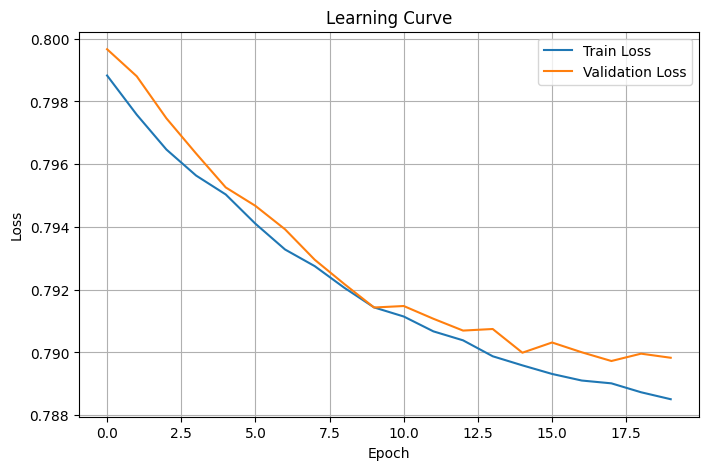

function: plot_learning_curve successfully executed at 0.2902817726135254s


In [36]:
plot_learning_curve(train_losses, val_losses) #MAE

# Task Lookup Threshold 

### Predict and Test Performance

- หลังจากได้โมเดล เราลองใส่ X_scaled_train_all เข้าไปเพื่อให้ได้  y_predict
- แล้วทดสอบผลกับ true_fraud_list

In [37]:
recon_error_train = get_reconstruction_error(trained_model, X_scaled_train_all,loss_name="mae")
recon_error_train

function: get_reconstruction_error is starting...
[INFO] Reconstruction error calculated using MAE for 8000 samples
[INFO] Error stats -> min: 0.5531, max: 3.8165, mean: 0.9119
function: get_reconstruction_error successfully executed at 0.03834795951843262s


array([0.77432275, 0.87345445, 0.5838824 , ..., 0.8835308 , 0.9002129 ,
       0.7599772 ], shape=(8000,), dtype=float32)

In [38]:
lookup_pct_threshold = evaluate_thresholds(x_scaled = X_scaled_train_all , 
                                            train_all_df=train_all_df ,
                                            y_train_all=y_train_all , 
                                            recon_error=recon_error_train ,
                                            true_fraud_list=true_fraud_list)
lookup_pct_threshold

function: evaluate_thresholds is starting...
function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 6.222724914550781e-05s
function: create_pack_results is starting...
function: create_pack_results successfully executed at 0.00027060508728027344s
function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 4.3392181396484375e-05s
function: create_pack_results is starting...
function: create_pack_results successfully executed at 0.0001938343048095703s
function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 2.6464462280273438e-05s
function: create_pack_results is starting...
function: create_pack_results successfully executed at 0.00010085105895996094s
function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 4.744529724121094e-05s
function: create_pack_results is starting...
function: create_pack_results successfully executed at 0.00018477439880371094s
functi

100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 59.63it/s]

function: evaluate_fraud_predictions successfully executed at 0.2240147590637207s
function: evaluate_thresholds successfully executed at 0.24459195137023926s


,experiments,total_alert,tp,fp,tn,fn,precision,recall,f0.5,f1
0,ae_default_all_p10,7237,379,6858,763,0,0.052370,1.0,0.064616,0.099527
1,ae_default_all_p20,6475,379,6096,1525,0,0.058533,1.0,0.072111,0.110592
2,ae_default_all_p30,5713,379,5334,2287,0,0.066340,1.0,0.081572,0.124425
3,ae_default_all_p40,4951,379,4572,3049,0,0.076550,1.0,0.093891,0.142214
4,ae_default_all_p50,4189,379,3810,3811,0,0.090475,1.0,0.110592,0.165937
5,ae_default_all_p60,3427,379,3048,4573,0,0.110592,1.0,0.134521,0.199159
6,ae_default_all_p70,2665,379,2286,5335,0,0.142214,1.0,0.171664,0.249014
7,ae_default_all_p80,1903,379,1524,6097,0,0.199159,1.0,0.237142,0.332165
8,ae_default_all_p85,1522,379,1143,6478,0,0.249014,1.0,0.293026,0.398738
9,ae_default_all_p90,1141,379,762,6859,0,0.332165,1.0,0.383370,0.498684


In [39]:
# Pick a threshold (e.g., 95th percentile of normal errors)
threshold = np.percentile(recon_error_train[y_train_all == 0], 95)
threshold

np.float32(0.9345768)

In [40]:
# Flag anomalies
y_pred_train = flag_anomalies(recon_error_train, threshold)
y_pred_train

function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 0.000301361083984375s


array([0, 0, 0, ..., 0, 0, 0], shape=(8000,))

#### get threshold cutoff

In [41]:
thresholds_df = get_thresholds(recon_error=recon_error_train, 
                               y_train_all = y_train_all
                               , exp_name="all")
thresholds_df

function: get_thresholds is starting...
function: get_thresholds successfully executed at 0.0562131404876709s


,percentile,threshold_value
0,1,0.625195
1,2,0.646955
2,3,0.657996
3,4,0.666382
4,5,0.675812
...,...,...
95,96,0.943242
96,97,0.955339
97,98,0.969379
98,99,0.988468


# Task Evaluate with Test dataset

In [42]:
# get recon
recon_error_test = get_reconstruction_error(trained_model, X_scaled_test,loss_name="mae")
recon_error_test

function: get_reconstruction_error is starting...
[INFO] Reconstruction error calculated using MAE for 2000 samples
[INFO] Error stats -> min: 0.5232, max: 3.6293, mean: 0.9155
function: get_reconstruction_error successfully executed at 0.0070874691009521484s


array([0.9067156 , 0.8650018 , 0.7530765 , ..., 2.992853  , 0.72391725,
       0.7426156 ], shape=(2000,), dtype=float32)

In [43]:
# Flag anomalies
y_pred_test = flag_anomalies(recon_error_test, threshold)
y_pred_test

function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 0.00017571449279785156s


array([0, 0, 0, ..., 1, 0, 0], shape=(2000,))

## [TEST] Packing

In [47]:
result_test_df = create_pack_results_date(test_df, y_pred_test, experiment_name='ae_test_1')
result_test_df

function: create_pack_results_date is starting...
function: create_pack_results_date successfully executed at 0.0008389949798583984s


,sales_id,expected_dt,ae_test_1
0,8751,2024-12-26,0
1,3108,2024-11-01,0
2,7395,2025-05-09,0
3,1373,2024-08-04,0
4,1858,2024-11-11,0
...,...,...,...
1995,3178,2025-04-29,0
1996,9980,2025-02-08,0
1997,1440,2025-02-17,1
1998,8684,2024-12-05,0


In [48]:
result_test_no_date = create_pack_results(test_df, y_pred_test, experiment_name='ae_test_1')
result_test_no_date = result_test_no_date.set_index(['sales_id'])
result_test_no_date

function: create_pack_results is starting...
function: create_pack_results successfully executed at 0.0005528926849365234s


,ae_test_1
sales_id,
8751,0
3108,0
7395,0
1373,0
1858,0
...,...
3178,0
9980,0
1440,1


In [49]:
ae_default_test_results_df = evaluate_fraud_predictions(
                                x_scaled=X_scaled_test,
                                df_lables=result_test_no_date,
                                true_fraud_list=true_fraud_list
                            )
ae_default_test_results_df

function: evaluate_fraud_predictions is starting...
Total input: 2000


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 46.01it/s]

function: evaluate_fraud_predictions successfully executed at 0.029718399047851562s


,experiments,total_alert,tp,fp,tn,fn,precision,recall,f0.5,f1
0,ae_test_1,189,95,94,1811,0,0.502646,1.0,0.558167,0.669014


# [ALL] Task Visualize

In [50]:
# get recon
recon_error_all = get_reconstruction_error(trained_model, X_scaled_all,loss_name="mae")
recon_error_all

function: get_reconstruction_error is starting...
[INFO] Reconstruction error calculated using MAE for 10000 samples
[INFO] Error stats -> min: 0.5232, max: 3.8165, mean: 0.9126
function: get_reconstruction_error successfully executed at 0.007421731948852539s


array([0.77432275, 0.87345445, 0.5838824 , ..., 2.992853  , 0.72391725,
       0.7426156 ], shape=(10000,), dtype=float32)

In [51]:
# Flag anomalies
y_pred_all = flag_anomalies(recon_error_all, threshold)
y_pred_all

function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 0.0003097057342529297s


array([0, 0, 0, ..., 1, 0, 0], shape=(10000,))

In [52]:
embeddings_all = extract_embeddings(trained_model, X_scaled_all)

function: extract_embeddings is starting...
[INFO] Using device: cpu
[INFO] Input shape: torch.Size([10000, 60])
[INFO] Extracted embeddings shape: (10000, 3)
function: extract_embeddings successfully executed at 0.004728555679321289s


In [53]:
embeddings_all

array([[ 0.24774686,  0.45480636,  0.01115732],
       [ 0.3170731 ,  0.14919186,  0.3642548 ],
       [-0.17196174, -0.08373005, -0.0038711 ],
       ...,
       [ 2.4055262 ,  2.173281  ,  0.6366803 ],
       [ 0.12461222,  0.01849874,  0.29982048],
       [-0.0205635 , -0.2628031 ,  0.39686006]],
      shape=(10000, 3), dtype=float32)

In [73]:
from package.model_deep_ae_20250829 import (
                                plot_latent_space_2d,
                                plot_latent_space_3d,)

In [59]:
# plot_latent_space_2d(
#     embeddings=embeddings_all,
#     y_test=y_all,
#     y_pred=y_pred_all,
#     index_df=all_df,        # DataFrame to use for hover info
#     hover_col='sales_id'     # column in test_df to display on hover
# )

In [60]:
# plot_latent_space_3d(
#     embeddings=embeddings_all,
#     y_test=y_all,
#     y_pred=y_pred_all,
#     index_df=all_df,        # DataFrame to use for hover info
#     hover_col='sales_id'     # column in test_df to display on hover
# )

In [74]:
pd.DataFrame({
    "y_all": pd.Series(y_all).value_counts(),
    "y_pred_all": pd.Series(y_pred_all).value_counts()
}).fillna(0).astype(int)

,y_all,y_pred_all
0,9526,9051
1,474,949


# [ALL] Get predict pct
เอา recon มาเรียงแล้วตรวจว่า pct เท่าไหร่ -> เอา recon วิ่งผ่าน lookup แล้วบอกว่าอยู่ pct เท่าไหร่ (new) 

In [75]:
mapped_percentiles_all = map_errors_to_percentiles(recon_error = recon_error_all, thresholds_df=thresholds_df)
mapped_percentiles_all

function: map_errors_to_percentiles is starting...
function: map_errors_to_percentiles successfully executed at 0.0016164779663085938s


array([0.36, 0.81, 0.01, ..., 1.  , 0.16, 0.22], shape=(10000,))

## [ALL] Packing

In [76]:
# Percentile
result_pct_all_df = create_pack_results_date(all_df, mapped_percentiles_all, experiment_name='pct_ae')
result_pct_all_df

function: create_pack_results_date is starting...
function: create_pack_results_date successfully executed at 0.0015287399291992188s


,sales_id,expected_dt,pct_ae
0,3630,2025-01-09,0.36
1,5986,2024-09-11,0.81
2,7036,2025-05-28,0.01
3,628,2025-01-09,0.70
4,6352,2024-11-30,0.08
...,...,...,...
9995,3178,2025-04-29,0.57
9996,9980,2025-02-08,0.30
9997,1440,2025-02-17,1.00
9998,8684,2024-12-05,0.16


In [77]:
# LABEL 0/1
result_label_all_df = create_pack_results_date(all_df, y_pred_all, experiment_name='label_ae')
result_label_all_df

function: create_pack_results_date is starting...
function: create_pack_results_date successfully executed at 0.001013040542602539s


,sales_id,expected_dt,label_ae
0,3630,2025-01-09,0
1,5986,2024-09-11,0
2,7036,2025-05-28,0
3,628,2025-01-09,0
4,6352,2024-11-30,0
...,...,...,...
9995,3178,2025-04-29,0
9996,9980,2025-02-08,0
9997,1440,2025-02-17,1
9998,8684,2024-12-05,0


In [78]:
# result_label_all_df.to_csv('data/result_label_all_df.csv',index=False)

## Predict Train label for surrogate

In [ ]:
# Surrogate will predict in surrogate_model.ipynb

In [82]:
# LABEL 0/1
result_label_train_df = create_pack_results_date(train_all_df, y_pred_train, experiment_name='label_ae')
result_label_train_df

function: create_pack_results_date is starting...
function: create_pack_results_date successfully executed at 0.0021436214447021484s


,sales_id,expected_dt,label_ae
0,3630,2025-01-09,0
1,5986,2024-09-11,0
2,7036,2025-05-28,0
3,628,2025-01-09,0
4,6352,2024-11-30,0
...,...,...,...
7995,9252,2024-12-25,0
7996,5428,2024-12-16,0
7997,5860,2025-02-21,0
7998,5684,2025-05-12,0


In [83]:
# result_label_train_df.to_csv('data/result_label_train_df.csv',index=False)

# Cluster Embedding Layer

In [1]:
from package.model_dbscan import *
from package.evaluation import *

## prepare data - embedding

In [ ]:
np.save("dump_np/embeddings_all.npy", embeddings_all)

In [ ]:
embeddings_all = np.load("dump_np/embeddings_all.npy")
embeddings_all

In [ ]:
embeddings_train_all = extract_embeddings(trained_model, X_scaled_train_all)
embeddings_train_all

In [ ]:
np.save("dump_np/embeddings_train_all.npy", embeddings_train_all)

In [ ]:
embeddings_train_all = np.load("dump_np/embeddings_train_all.npy")
embeddings_train_all

In [ ]:
embeddings_test = extract_embeddings(trained_model, X_scaled_test)
embeddings_test

In [ ]:
np.save("dump_np/embeddings_test.npy", embeddings_test)

In [ ]:
embeddings_test = np.load("dump_np/embeddings_test.npy")
embeddings_test

## plot k distance

In [ ]:
def plot_k_distance_graphs(X, k_values):
    plt.figure(figsize=(10, 6))
    for k in k_values:
        neigh = NearestNeighbors(n_neighbors=k)
        neigh.fit(X)
        distances, _ = neigh.kneighbors(X)
        distances = np.sort(distances[:, k-1])
        plt.plot(distances, label=f'k={k}')
    
    plt.xlabel('Points')
    plt.ylabel('k-th nearest neighbor distance')
    plt.title('K-distance Graphs for different k')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.neighbors import NearestNeighbors

# ใช้หลายค่า k ดู
plot_k_distance_graphs(embeddings_train_all, [3+1])

In [ ]:
@timer
def dbscan_grid_search(
        X_train,
        y_train=None,
        X_test=None,
        y_test=None,
        # transformer=None,
        s3_bucket=None,
        s3_prefix="dbscan_experiments",
        eps_list=[0.5, 1.0],
        min_samples_list=[5, 10],
        metric="euclidean",
        pct_list=[75,80,85,90, 95, 97, 99],
    ):
    """
    DBSCAN grid search with train/test performance and S3 upload.
    """
    X_train_scaled = X_train
    X_test_scaled = X_test

    results = []

    for eps, min_samples in tqdm(list(product(eps_list, min_samples_list))):
        run_id = f"{str(uuid.uuid4())}_{datetime.datetime.now().strftime('%Y%m%d%H%M%S')}"
        prefix = f"{s3_prefix}/{run_id}" if s3_prefix else run_id
        
        # Fit DBSCAN
        clusterer = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
        labels_train = clusterer.fit_predict(X_train_scaled)
        y_pred_train = (labels_train==-1).astype(int)
        
        # Train performance
        perf_train = calculate_performance(y_pred_train, y_train, suffix="train")

        # Test performance
        if X_test is not None:
            labels_test = dbscan_predict(clusterer, X_test_scaled, metric=metric)
            y_pred_test = (labels_test==-1).astype(int)
            perf_test = calculate_performance(y_pred_test, y_test, suffix="test")
        else:
            perf_test = {}

        perf_metrics = {**perf_train, **perf_test}
        perf_metrics['experiments'] = {
            'eps': eps, 
            'min_samples': min_samples, 
            'metric': metric, 
            'pct':0,
            'thresh': 0
        }
        perf_metrics['n_features'] = X_train.shape[1]
        perf_metrics['id'] = run_id

        df = pd.concat([
            make_df(X_train_scaled, y_pred_train, y_train, 'train_set'),
            make_df(X_test_scaled, y_pred_test, y_test, 'test_set')], axis=0, ignore_index=True)

        # Generate binary flags + evaluate
        cut_rows = evaluate_percentile_cuts_generic(
            df=df,
            X_train=X_train,
            y_train=y_train,
            y_test=y_test,
            pct_list=pct_list,
            eps=eps,
            min_samples=min_samples,
            min_cluster_size=None,
            metric=metric,
            run_id=run_id,
            n_features=X_train.shape[1],
            algo="dbscan")

        # Combine baseline + cut rows
        all_perf_rows = [perf_metrics] + cut_rows

        # Upload files
        upload_bytes(all_perf_rows, s3_bucket, f"{prefix}/performance.json")
        # upload_bytes(X_train.columns.tolist(), s3_bucket, f"{prefix}/feature.json")
        upload_bytes(clusterer, s3_bucket, f"{prefix}/model.pkl", is_pickle=True)
        # upload_bytes(transformer, s3_bucket, f"{prefix}/transformer.pkl", is_pickle=True)
        # Upload distance dataframe
        # upload_bytes(df[['y_pred','y_true','data_set','dist']], s3_bucket, f"{prefix}/distance_cut_percentile.csv")
        df[['y_pred','y_true','data_set','dist']].to_csv(f"s3://{s3_bucket}/{s3_prefix}/{run_id}/distance_cut_percentile.csv", index=False)
        results.append({'s3_prefix': prefix, **perf_metrics})

In [ ]:
%%time
dbscan_grid_search(
    X_train=embeddings_train_all,
    y_train=y_train_all,
    X_test=embeddings_test,
    y_test=y_test,
    # transformer=transformer,
    s3_bucket='tli-sas-analytic-based-table',
    s3_prefix='sandbox/fraud-detection/fraud_agent_ml/model/autoencoder/20250910_092135',
    eps_list=np.arange(0.1, 1+1, 0.1).round(1).tolist(),
    min_samples_list=list(range(3, 8, 1)),
    metric="euclidean",
    pct_list=[75,80,85,90, 95, 97, 99])

## read performance

In [ ]:
%%time
all_perf = read_performance_to_df('tli-sas-analytic-based-table', 
                                  'sandbox/fraud-detection/fraud_agent_ml/model/autoencoder/20250910_092135')

In [ ]:
all_perf.sort_values(by='test_f0.5',ascending=False).head(10)

In [ ]:
all_perf_ex = all_perf['experiments']
all_perf_ex = pd.json_normalize(all_perf_ex)
all_perf_ex = pd.concat([all_perf,all_perf_ex],axis=1)
all_perf_ex = all_perf_ex.sort_values(by='test_f0.5',ascending=False).head(10)
all_perf_ex

## select predict

In [ ]:
ids = all_perf.sort_values(by='test_f0.5',ascending=False).head(1)['id'].values[0]
ids

In [ ]:
# Example usage
s3_bucket = "tli-sas-analytic-based-table"
# transformer_key = f"sandbox/fraud-detection/fraud_agent_ml/model/dbscan_full_feature_asis/{ids}/transformer.pkl"
# select_transformer = load_model(s3_bucket, transformer_key)

# x_train_scaled = select_transformer.transform(X_train)
# x_test_scaled = select_transformer.transform(X_test)

model_key = f"sandbox/fraud-detection/fraud_agent_ml/model/autoencoder/20250910_092135/{ids}/model.pkl"
select_model = load_model(s3_bucket, model_key)

In [ ]:
%%time
# ✅ Now you can use it
y_pred_train = dbscan_predict(select_model, embeddings_train_all, 'euclidean')
y_pred_train = (y_pred_train == -1).astype(int)
calculate_performance(y_pred_train, y_train_all, suffix="train")

In [ ]:
%%time
# ✅ Now you can use it
y_pred_test = dbscan_predict(select_model, embeddings_test, 'euclidean')
y_pred_test = (y_pred_test == -1).astype(int)
calculate_performance(y_pred_test, y_test, suffix="test")

In [ ]:
pd.DataFrame([calculate_performance(y_pred_train, y_train_all, suffix="_"), calculate_performance(y_pred_test, y_test, suffix="_")],index=['train','test'])

In [ ]:
ids_train = train_all_df.loc[:,['sales_id','expected_dt']]
ids_train

In [ ]:
ids_test = test_df.loc[:,['sales_id','expected_dt']]
ids_test

In [ ]:
ae_result_emb_db_all = pd.concat([ids_train,ids_test],axis=0)
ae_result_emb_db_all['label_emb_db'] = np.concatenate([y_pred_train, y_pred_test], axis=0)
ae_result_emb_db_all = ae_result_emb_db_all.reset_index(drop=True)
ae_result_emb_db_all

In [ ]:
plot_latent_space_2d(
    embeddings=embeddings_test,
    y_test=y_test,
    y_pred=y_pred_test,
    index_df=test_df,        # DataFrame to use for hover info
    hover_col='sales_id'     # column in test_df to display on hover
)

# Pipeline

In [85]:
# design arch
in_x = X_scaled_train.shape[1]# จำนวน features -> input_dim
h1 = X_scaled_train.shape[1]//4 #  -> number of neuron in hidden layer 1
h2 = X_scaled_train.shape[1]//16 # -> hidden 2
# h3 = X_scaled_train.shape[1]//32 # -> hidden 3

print(f'input layer dim = {in_x}')
print(f'hidden layer dim #1 = {h1}')
print(f'hidden layer dim #2 = {h2}')
# print(f'hidden layer dim #3 = {h3}')

hidden_layers_list = [h1,h2]
print(hidden_layers_list)

input layer dim = 60
hidden layer dim #1 = 15
hidden layer dim #2 = 3
[15, 3]


function: run_training_pipeline is starting...
function: set_seed is starting...
function: set_seed successfully executed at 0.006337404251098633s

===== Autoencoder Architecture =====
Layer (type:depth-idx)                   Output Shape              Param #
Autoencoder                              [5, 60]                   --
├─Sequential: 1-1                        --                        --
│    └─Linear: 2-1                       [5, 15]                   915
│    └─ReLU: 2-2                         [5, 15]                   --
│    └─Dropout: 2-3                      [5, 15]                   --
│    └─Linear: 2-4                       [5, 3]                    48
│    └─ReLU: 2-5                         [5, 3]                    --
│    └─Dropout: 2-6                      [5, 3]                    --
│    └─Linear: 2-7                       [5, 3]                    12
├─Sequential: 1-2                        --                        --
│    └─Linear: 2-8                     

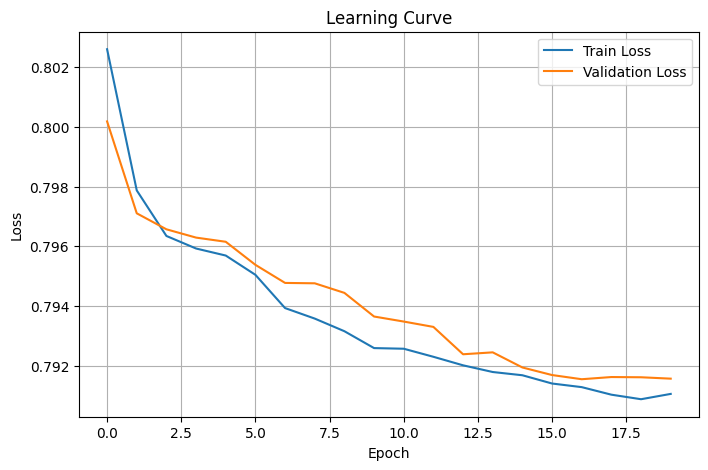

function: plot_learning_curve successfully executed at 0.1544198989868164s
function: run_training_pipeline successfully executed at 8.068095207214355s


In [86]:
trained_model, train_losses, val_losses = run_training_pipeline(
    input_dim = in_x,
    encoding_dim = 3 ,
    hidden_layers_list = hidden_layers_list,
    dropout = 0.2,
    X_scaled_train = X_scaled_train,
    X_scaled_val = X_scaled_val,
    seed= 42,
    epochs = 20,
    checkpoint_every  = 10,
    early_stopping_patience = 10,
    run_dir= "model_checkpoint",
    loss_name = "mae",
    optimizer_name = "adam",
    # scheduler_name=None,
    scheduler_name="plateau",
    # scheduler_params=None,
    scheduler_params={"factor": 0.2, "patience": 5
    #                   # ,"step_size":5
                     },
)

In [88]:
trained_model

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=60, out_features=15, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=15, out_features=3, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=3, out_features=3, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=3, out_features=3, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=3, out_features=15, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=15, out_features=60, bias=True)
  )
)

In [93]:
(recon_error_train, 
 lookup_pct_threshold, 
 chosen_threshold, 
 y_pred_train ) = run_lookup_threshold_pipeline(trained_model = trained_model,
                                  X_scaled_train_all = X_scaled_train_all,
                                  train_all_df = train_all_df,
                                  y_train_all = y_train_all,
                                  true_fraud_list = true_fraud_list,
                                  loss_name="mae",
                                  percentile=95)

function: run_lookup_threshold_pipeline is starting...
function: get_reconstruction_error is starting...
[INFO] Reconstruction error calculated using MAE for 8000 samples
[INFO] Error stats -> min: 0.5496, max: 3.7643, mean: 0.8970
function: get_reconstruction_error successfully executed at 0.0106658935546875s
function: evaluate_thresholds is starting...
function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 0.0007176399230957031s
function: create_pack_results is starting...
function: create_pack_results successfully executed at 0.0016295909881591797s
function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 0.0008826255798339844s
function: create_pack_results is starting...
function: create_pack_results successfully executed at 0.0012493133544921875s
function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 0.0009129047393798828s
function: create_pack_results is starting...
function: cre

100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 51.53it/s]


function: evaluate_fraud_predictions successfully executed at 0.2638852596282959s
function: evaluate_thresholds successfully executed at 0.343961238861084s
function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 0.0008349418640136719s
function: run_lookup_threshold_pipeline successfully executed at 0.3610086441040039s


In [95]:
recon_error_train

array([0.7566044 , 0.85529894, 0.5794928 , ..., 0.8559658 , 0.8776988 ,
       0.76670283], shape=(8000,), dtype=float32)

In [96]:
lookup_pct_threshold

,experiments,total_alert,tp,fp,tn,fn,precision,recall,f0.5,f1
0,ae_default_all_p10,7237,379,6858,763,0,0.052370,1.0,0.064616,0.099527
1,ae_default_all_p20,6475,379,6096,1525,0,0.058533,1.0,0.072111,0.110592
2,ae_default_all_p30,5713,379,5334,2287,0,0.066340,1.0,0.081572,0.124425
3,ae_default_all_p40,4951,379,4572,3049,0,0.076550,1.0,0.093891,0.142214
4,ae_default_all_p50,4189,379,3810,3811,0,0.090475,1.0,0.110592,0.165937
5,ae_default_all_p60,3427,379,3048,4573,0,0.110592,1.0,0.134521,0.199159
6,ae_default_all_p70,2665,379,2286,5335,0,0.142214,1.0,0.171664,0.249014
7,ae_default_all_p80,1903,379,1524,6097,0,0.199159,1.0,0.237142,0.332165
8,ae_default_all_p85,1522,379,1143,6478,0,0.249014,1.0,0.293026,0.398738
9,ae_default_all_p90,1141,379,762,6859,0,0.332165,1.0,0.383370,0.498684


In [97]:
chosen_threshold

np.float32(0.91878814)

In [98]:
y_pred_train

array([0, 0, 0, ..., 0, 0, 0], shape=(8000,))

In [101]:
(recon_error_test, 
 y_pred_test, 
 result_test_df) = run_evaluate_test_pipeline(trained_model = trained_model, 
                               X_scaled_test = X_scaled_test, 
                               test_df = test_df, 
                               threshold =  chosen_threshold, 
                               experiment_name="ae_test_1",
                               loss_name="mae")

function: run_evaluate_test_pipeline is starting...
function: get_reconstruction_error is starting...
[INFO] Reconstruction error calculated using MAE for 2000 samples
[INFO] Error stats -> min: 0.5206, max: 3.5801, mean: 0.9006
function: get_reconstruction_error successfully executed at 0.0069887638092041016s
function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 0.0006504058837890625s
function: create_pack_results_date is starting...
function: create_pack_results_date successfully executed at 0.0025675296783447266s
function: run_evaluate_test_pipeline successfully executed at 0.0138397216796875s


In [102]:
recon_error_test

array([0.87132806, 0.8179615 , 0.7502983 , ..., 2.917852  , 0.70231324,
       0.7217138 ], shape=(2000,), dtype=float32)

In [103]:
y_pred_test

array([0, 0, 0, ..., 1, 0, 0], shape=(2000,))

In [104]:
result_test_df

,sales_id,expected_dt,ae_test_1
0,8751,2024-12-26,0
1,3108,2024-11-01,0
2,7395,2025-05-09,0
3,1373,2024-08-04,0
4,1858,2024-11-11,0
...,...,...,...
1995,3178,2025-04-29,0
1996,9980,2025-02-08,0
1997,1440,2025-02-17,1
1998,8684,2024-12-05,0


function: run_vis_embedding_pipeline is starting...
function: get_reconstruction_error is starting...
[INFO] Reconstruction error calculated using MAE for 10000 samples
[INFO] Error stats -> min: 0.5206, max: 3.7643, mean: 0.8977
function: get_reconstruction_error successfully executed at 0.012592792510986328s
function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 0.001233816146850586s
function: extract_embeddings is starting...
[INFO] Using device: cpu
[INFO] Input shape: torch.Size([10000, 60])
[INFO] Extracted embeddings shape: (10000, 3)
function: extract_embeddings successfully executed at 0.006559610366821289s
function: plot_latent_space_2d is starting...


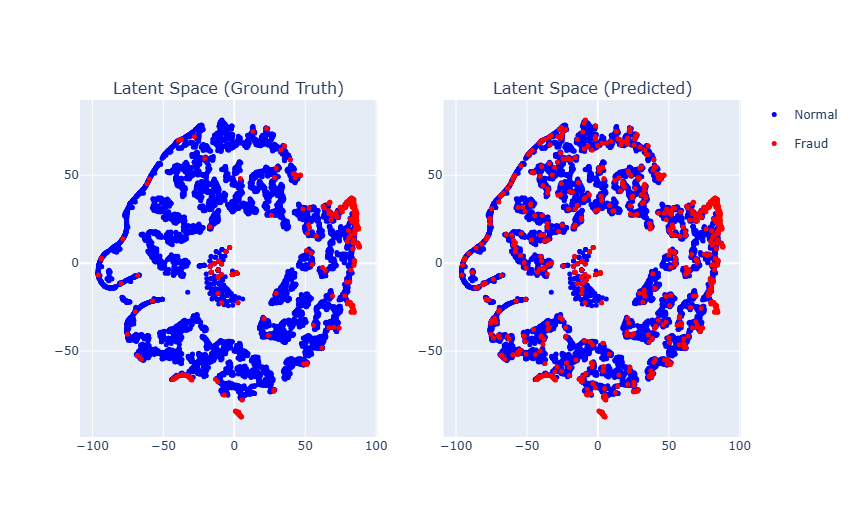

function: plot_latent_space_2d successfully executed at 33.97282648086548s
function: create_pack_results_date is starting...
function: create_pack_results_date successfully executed at 0.0026917457580566406s
function: run_vis_embedding_pipeline successfully executed at 34.001580476760864s


In [109]:
(recon_error_all, 
 y_pred_all, 
 embeddings_all, 
 result_all_df) = run_vis_embedding_pipeline(
                            model=trained_model,
                            X_data=X_scaled_all,
                            y_data=y_all,
                            index_df=all_df,
                            hover_col="sales_id",
                            threshold=chosen_threshold,
                            experiment_name="ae_all_1",
                            plot_type="2d"  # "2d", "3d", or "both"
                            )

In [110]:
recon_error_all

array([0.7566044 , 0.85529894, 0.5794928 , ..., 2.917852  , 0.70231324,
       0.7217138 ], shape=(10000,), dtype=float32)

In [111]:
y_pred_all

array([0, 0, 0, ..., 1, 0, 0], shape=(10000,))

In [112]:
embeddings_all

array([[ 1.7630102e-01, -1.7938402e-01,  5.8124924e-01],
       [ 5.3802812e-01,  4.8897722e-01,  5.4367495e-01],
       [ 3.5778609e-01,  2.6099086e-03,  9.9185407e-01],
       ...,
       [ 2.0217724e+00,  1.7870662e+00,  5.8489542e+00],
       [ 8.9475936e-01,  6.0831761e-01,  1.4517188e+00],
       [ 3.0088973e-01, -1.2480107e-01,  1.6622227e+00]],
      shape=(10000, 3), dtype=float32)

In [113]:
result_all_df

,sales_id,expected_dt,ae_all_1
0,3630,2025-01-09,0
1,5986,2024-09-11,0
2,7036,2025-05-28,0
3,628,2025-01-09,0
4,6352,2024-11-30,0
...,...,...,...
9995,3178,2025-04-29,0
9996,9980,2025-02-08,0
9997,1440,2025-02-17,1
9998,8684,2024-12-05,0


# Laplacian
https://www.numberanalytics.com/blog/laplacian-eigenmaps-dimensionality-reduction

In [35]:
import numpy as np
from scipy.spatial import distance
import plotly.express as px
import pandas as pd

@timer
def plot_laplacian_eigenmaps_3d(X_scaled_test, y_test, test_df, hover_col='sales_id', n_components=3, sigma=1.0, title="3D Laplacian Eigenmaps"):
    """
    Compute 3D Laplacian Eigenmaps and plot with Plotly.
    y_test should be discrete (0/1).
    
    Parameters:
    - X_scaled_test: np.array or pd.DataFrame of test features
    - y_test: np.array or pd.Series of discrete labels (0/1)
    - test_df: pd.DataFrame containing hover column
    - hover_col: column name to show on hover
    - n_components: number of eigenmaps (default 3)
    - sigma: RBF kernel parameter
    """
    # Weight matrix
    W = np.exp(-distance.cdist(X_scaled_test, X_scaled_test, 'sqeuclidean') / (2 * sigma ** 2))
    D = np.diag(np.sum(W, axis=1))
    L = D - W

    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eig(L)
    idx = np.argsort(eigenvalues)
    
    # Take only real part
    X_3d = np.real(eigenvectors[:, idx[1:n_components+1]])

    # Prepare DataFrame
    df_plot = pd.DataFrame(X_3d, columns=[f'LE{i+1}' for i in range(n_components)])
    df_plot['y_test'] = y_test.astype(int).astype(str)  # cast to string for discrete colors
    df_plot[hover_col] = test_df[hover_col].values

    # 3D scatter plot with discrete colors and hover
    fig = px.scatter_3d(
        df_plot,
        x='LE1',
        y='LE2',
        z='LE3',
        color='y_test',
        color_discrete_map={'0': 'blue', '1': 'red'},
        hover_data=[hover_col],
        title=title,
        opacity=0.8
    )
    # fig.show()
    return fig

function: plot_laplacian_eigenmaps_3d is starting...
function: plot_laplacian_eigenmaps_3d successfully executed at 5.330060720443726s


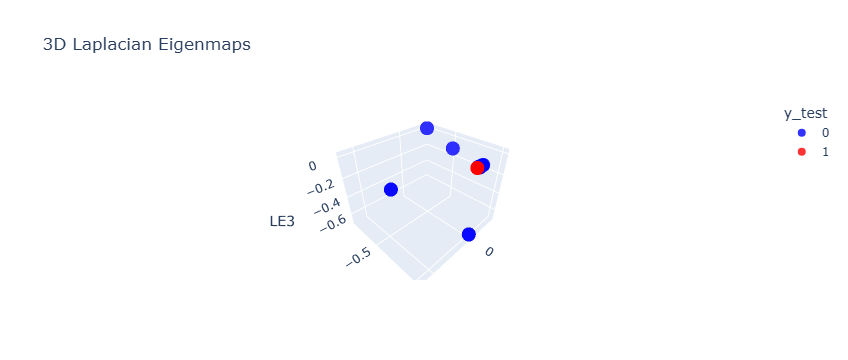

In [36]:
plot_laplacian_eigenmaps_3d(
    X_scaled_test=X_scaled_test,
    y_test=y_test,
    test_df=test_df,
    hover_col='sales_id',
    n_components=3,
    sigma=1.0
)

# [13-08-2025] ตัด label ว่า แล้วตัวที่ predict (แดง) อยู่่ใน่ กลุ่มก้อน 
หา overlap ว่าเกิดเท่าไหร่ 
มิติเล็กลงเห็นไร

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.cluster import DBSCAN
# from sklearn.preprocessing import StandardScaler

# def cluster_embeddings(embeddings, sales_ids=None, labels=None, eps=0.5, min_samples=5):
#     """
#     Cluster 3D embeddings using DBSCAN and visualize results.
    
#     Parameters:
#     - embeddings: np.ndarray (n_samples, 3)
#     - sales_ids: list or array of IDs (optional)
#     - labels: list or array of fraud labels (optional)
#     - eps: DBSCAN eps parameter
#     - min_samples: DBSCAN min_samples parameter
    
#     Returns:
#     - DataFrame with sales_id, cluster_id, and label (if provided)
#     """
    
#     # Standardize embeddings for DBSCAN
#     embeddings_scaled = StandardScaler().fit_transform(embeddings)
    
#     # Run DBSCAN
#     dbscan = DBSCAN(eps=eps, min_samples=min_samples)
#     cluster_ids = dbscan.fit_predict(embeddings_scaled)
    
#     # Prepare results DataFrame
#     df = pd.DataFrame({
#         "sales_id": sales_ids if sales_ids is not None else np.arange(len(embeddings)),
#         "cluster_id": cluster_ids
#     })
    
#     if labels is not None:
#         df["label"] = labels
    
#     # Plot results
#     fig = plt.figure(figsize=(14, 6))
    
#     ax1 = fig.add_subplot(121, projection='3d')
#     scatter1 = ax1.scatter(embeddings[:, 0], embeddings[:, 1], embeddings[:, 2],
#                            c=cluster_ids, cmap='tab10', s=20)
#     ax1.set_title("Clusters (DBSCAN)")
#     plt.colorbar(scatter1, ax=ax1, label="Cluster ID")
    
#     ax2 = fig.add_subplot(122, projection='3d')
#     if labels is not None:
#         scatter2 = ax2.scatter(embeddings[:, 0], embeddings[:, 1], embeddings[:, 2],
#                                c=labels, cmap='coolwarm', s=20)
#         ax2.set_title("Fraud vs Normal")
#         plt.colorbar(scatter2, ax=ax2, label="Label (0=Normal, 1=Fraud)")
#     else:
#         ax2.set_title("No Labels Provided")
    
#     plt.show()
    
#     return df


In [ ]:
# df_clusters = cluster_embeddings(
#     embeddings=embeddings,
#     sales_ids=np.arange(len(embeddings)),
#     labels=np.random.randint(0, 2, size=embeddings.shape[0]),  # Replace with your real labels
#     eps=0.5,
#     min_samples=5
# )
# df_clusters